In [47]:
import os
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import resample
from typing import List, Dict, Any

# Separamos manualmente los pacientes

In [48]:
patients_train = [
    '101', '102', '104', '105', '106', '107', '108', '109', '112', '113', 
    '114', '115', '116', '117', '118', '121', '122', '123', '200', '201', 
    '202', '205', '207', '208', '209', '210', '212', '213', '214', '215', 
    '219', '220', '221', '223', '228', '230', '231', '232', '234'
]

patients_test = [
    '100', '103', '111', '119', '124', '203', '217', '222', '233'
]

# Fusionamos la clase 3 (F) con la clase 2 (V)
### También pasamos la clase 4 a la 3

In [49]:
db_dir = "../data/mitdb_data"

def beats_extraction(patient_list: List, dir_path: str=db_dir, window_size: int=1500) -> List:
    """extraemos las features principales de los latidos, además de cambiar la frecuencia de 360Hz a 500Hz

    Args:
        patient_list (_type_): lista donde se encuentra el número de cada paciente
        dir_path (_type_, optional): directorio de donde están los datosoriginales del dataset. Defaults to db_dir.
        window_size (int, optional): tamaño de ventana total. Defaults to 1500.

    Returns:
        List: devuelve un array de numpy con los datos modificados
    """    
    X_signals = []
    X_rr_features = []
    y_labels = []
    
    aami_mapping = {'N':0, 'L':0, 'R':0, 'e':0, 'j':0, 
                    'A':1, 'a':1, 'J':1, 'S':1, 
                    'V':2, 'E':2, 'F':2, '/':3, 'f':3, 'Q':3}
    
    fs_target = 500  
    half_w = window_size // 2

    for patient in patient_list:
        record_path = os.path.join(dir_path, patient)
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, 'atr')
        
        num_samples = int(len(record.p_signal) * fs_target / record.fs)
        signals_resampled = resample(record.p_signal, num_samples)
        
        resample_factor = fs_target / record.fs
        peaks_resampled = np.array([int(p * resample_factor) for p in annotation.sample])
        symbols = annotation.symbol
        rr_intervals = np.diff(peaks_resampled)
        
        for i in range(1, len(peaks_resampled) - 1):
            sym = symbols[i]
            if sym not in aami_mapping:
                continue
                
            idx = peaks_resampled[i]
            if idx - half_w < 0 or idx + half_w > len(signals_resampled):
                continue
                
            beat_signal = signals_resampled[idx - half_w : idx + half_w, :]
            
            rr_previo = rr_intervals[i-1]
            rr_siguiente = rr_intervals[i]
            
            start_history = max(0, i-8)
            rr_local_mean = np.mean(rr_intervals[start_history:i]) + 1e-8
            
            # Ratios relativos locales
            rr_previo_rel = rr_previo / rr_local_mean
            rr_siguiente_rel = rr_siguiente / rr_local_mean
            rr_ratio_global = rr_previo / (rr_siguiente + 1e-8)

            # Captura explícitamente el salto de un latido prematuro a una pausa.
            # En S: (Largo - Corto) genera un número positivo muy alto. En Normal: ~0.0
            rr_diff_transicion = rr_siguiente_rel - rr_previo_rel
            
            X_signals.append(beat_signal)
            X_rr_features.append([rr_previo_rel, rr_siguiente_rel, rr_diff_transicion, rr_ratio_global])
            y_labels.append(aami_mapping[sym])
            
    return np.array(X_signals), np.array(X_rr_features), np.array(y_labels)

data_folder = "../data"
npy_dir = os.path.join(data_folder, "npy_data_mitbih_changed") # Nueva carpeta para no mezclar

print("Iniciando extracción cambiada con Normalización RR por Paciente...")
if not os.path.exists(npy_dir): os.makedirs(npy_dir)
    
X_train_sig, X_train_rr, y_train = beats_extraction(patients_train)
X_test_sig, X_test_rr, y_test   = beats_extraction(patients_test)

np.save(os.path.join(npy_dir, "X_train_sig.npy"), X_train_sig)
np.save(os.path.join(npy_dir, "X_train_rr.npy"), X_train_rr)
np.save(os.path.join(npy_dir, "y_train_mitbih.npy"), y_train)

np.save(os.path.join(npy_dir, "X_test_sig.npy"), X_test_sig)
np.save(os.path.join(npy_dir, "X_test_rr.npy"), X_test_rr)
np.save(os.path.join(npy_dir, "y_test_mitbih.npy"), y_test)
print("¡Extracción cambiada guardada en disco!")

Iniciando extracción cambiada con Normalización RR por Paciente...
¡Extracción cambiada guardada en disco!


Definimos nuestra función de normalización.

In [50]:
def normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mean) / std, mean, std

X_train_sig_norm, _, _ = normalize(X_train_sig)
X_test_sig_norm, _, _ = normalize(X_test_sig)

Aplicamos RUS a la clase 0 (latido normal) debido al desbalance extremo.

In [51]:
from imblearn.under_sampling import RandomUnderSampler
from tensorflow.keras.utils import to_categorical

n_samples, timesteps, channels = X_train_sig_norm.shape
X_flat = X_train_sig_norm.reshape(n_samples, timesteps * channels)

rus = RandomUnderSampler(sampling_strategy= {0: 40000}, random_state=42)

X_res, y_res = rus.fit_resample(X_flat, y_train)

X_train_rus = X_res.reshape(-1, timesteps, channels)
# Extraemos los intervalos RR correspondientes a las muestras seleccionadas por el RUS
X_train_rr_rus = X_train_rr[rus.sample_indices_]

Definimos nuestra función que para hacer un oversampling a las clases minoritarias, realizando pequeños cambios fisiológicos que son perfectamente posibles.

In [52]:
def augment_beat(beat, rr_features):
    """
    Aplica transformaciones morfológicas físicamente plausibles 
    sobre un latido de ECG de 1500 muestras.
    """
    # Ruido gaussiano blanco (simula interferencia muscular o del cable)
    noise_std = 0.015 * np.std(beat)
    beat_aug = beat + np.random.normal(0, noise_std, beat.shape)

    # Shift temporal suave (mueve el pico R ±20 muestras de forma realista)
    shift = np.random.randint(-20, 20)
    beat_aug = np.roll(beat_aug, shift, axis=0)

    # Escalado de amplitud (simula variaciones de voltaje de ±5%)
    scale = np.random.uniform(0.95, 1.05)
    beat_aug *= scale

    return beat_aug, rr_features

Aplicamos la función de oversampling a la clase S y ponemos las etiquetas como OneHot para que sea más manejable por nuestro modelo.

In [53]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
import numpy as np

y_train_mapped = y_res.copy()
y_test_mapped  = y_test.copy()

print("Aplying temporal augmentation to the S class in train...")
X_aug_sig, X_aug_rr, y_aug = [], [], []
idx_S = np.where(y_train_mapped == 1)[0]

for i in idx_S:
    for _ in range(2):
        s, r = augment_beat(X_train_rus[i], X_train_rr_rus[i])
        X_aug_sig.append(s)
        X_aug_rr.append(r)
        y_aug.append(1)

X_train_sig_final = np.concatenate([X_train_rus, np.array(X_aug_sig)])
X_train_rr_final  = np.concatenate([X_train_rr_rus, np.array(X_aug_rr)])
y_train_final     = np.concatenate([y_train_mapped, np.array(y_aug)])

y_train_m2_onehot = to_categorical(y_train_final, num_classes=4)
y_test_m2_onehot  = to_categorical(y_test_mapped, num_classes=4)

print("Escalando las características de ritmo...")
scaler_multi = StandardScaler()
X_train_rr_final_norm = scaler_multi.fit_transform(X_train_rr_final)
X_test_rr_final_norm = scaler_multi.transform(X_test_rr)

print("\n" + "="*60)
print("LIST ESTRUCTURE (4 CLASES)")
print("="*60)
print(f"  Final train signal: {X_train_sig_final.shape}")
print(f"  Final RR-peak train branch: {X_train_rr_final_norm.shape}")

Aplying temporal augmentation to the S class in train...
Escalando las características de ritmo...

LIST ESTRUCTURE (4 CLASES)
  Final train signal: (59795, 1500, 2)
  Final RR-peak train branch: (59795, 4)


# Entrenamiento del modelo

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense, RepeatVector, TimeDistributed, UpSampling1D,
                                     Conv1DTranspose, Input, Bidirectional, concatenate, BatchNormalization, Dropout,
                                     SpatialDropout1D, GlobalAveragePooling1D, Reshape, multiply, GlobalMaxPooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

Para este modelo se ha optado por 3 capas convolucionales de distintos tamaños de kernel , además de usar capas de atención SE (Squeeze and excitation) y un par de capas de LSTM bilaterales.
Para lospicos RR se ha usado 

In [55]:
def build_multimodal_network(window_size=1500, num_channels=2, rr_features_dim=4, output_classes=4):
    signal_input = Input(shape=(window_size, num_channels))

    conv_low = Conv1D(filters=16, kernel_size=5, padding="same", activation="relu")(signal_input)
    conv_mid = Conv1D(filters=16, kernel_size=15, padding="same", activation="relu")(signal_input)
    conv_high = Conv1D(filters=16, kernel_size=40, padding="same", activation="relu")(signal_input)
    conv_layer = concatenate([conv_low, conv_mid, conv_high])

    se_squeeze = GlobalAveragePooling1D()(conv_layer)
    se_ex1  = Dense(12, activation='relu', use_bias=False)(se_squeeze)
    se_ex2  = Dense(48, activation='sigmoid', use_bias=False)(se_ex1)
    se_scale = Reshape((1, 48))(se_ex2)
    conv_attended = multiply([conv_layer, se_scale])
    norm_1 = BatchNormalization()(conv_attended)

    lstm_1 = Bidirectional(LSTM(64, return_sequences=True))(norm_1)
    dropout_1 = SpatialDropout1D(0.3)(lstm_1)

    lstm_2 = Bidirectional(LSTM(32, return_sequences=True))(dropout_1)
    dropout_2 = SpatialDropout1D(0.3)(lstm_2)

    avg_pool = GlobalAveragePooling1D()(dropout_2)
    max_pool = GlobalMaxPooling1D()(dropout_2)
    signal_features = concatenate([avg_pool, max_pool])

    rr_input = Input(shape=(rr_features_dim,))
    rr_dense1 = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(rr_input)
    rr_norm1 = BatchNormalization()(rr_dense1)
    rr_dense2 = Dense(16, activation="relu")(rr_norm1)
    rr_features = BatchNormalization()(rr_dense2)

    rr_combined = concatenate([signal_features, rr_features])
    combined_norm = BatchNormalization()(rr_combined)

    dense_1 = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(combined_norm)
    dropout_3 = Dropout(0.4)(dense_1)
    dense_2 = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(dropout_3)
    output_layer = Dense(output_classes, activation='softmax')(dense_2)

    return Model(inputs=[signal_input, rr_input], outputs=output_layer)

model_multiclass = build_multimodal_network(output_classes=4)
model_multiclass.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1500, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 1500, 16)  │        176 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 1500, 16)  │        496 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 1500, 16)  │      1,296 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 1500, 48)  │          0 │ conv1d_9[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_10[0][0],  │
│                     │                   │            │ conv1d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ concatenate_9[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 12)        │        576 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 48)        │        576 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 48)     │          0 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 1500, 48)  │          0 │ concatenate_9[0]… │
│ (Multiply)          │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1500, 48)  │        192 │ multiply_3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 1500, 128) │     57,856 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_6 │ (None, 1500, 128) │          0 │ bidirectional_6[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 1500, 64)  │     41,216 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 32)        │        160 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_7 │ (None, 1500, 64)  │          0 │ bidirectional_7[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_23[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ spatial_dropout1

 Total params: 115,332 (450.52 KB)

 Trainable params: 114,852 (448.64 KB)

 Non-trainable params: 480 (1.88 KB)

Incluimos Poly focal loss.

In [56]:
def poly_focal_loss(gamma=2.0, epsilon=0.5, alpha_weights=None):
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)
        ce = -tf.reduce_sum(y_true * K.log(y_pred), axis=-1)
        
        focal_weight = K.pow(1.0 - pt, gamma)
        poly_weight = epsilon * K.pow(1.0 - pt, gamma + 1)
        
        total_loss = (focal_weight * ce) + poly_weight
        
        if alpha_weights is not None:
            at = tf.reduce_sum(alpha_weights * y_true, axis=-1)
            return at * total_loss
        
        return total_loss
    return loss

Y ahora hacemos los alpha_weights.

In [57]:
from sklearn.utils.class_weight import compute_class_weight

classes_m2 = np.unique(y_train_final)
class_weights_array_m2 = compute_class_weight(
    class_weight='balanced',
    classes=classes_m2,
    y=y_train_final
)

raw_weights_m2 = np.array([class_weights_array_m2[i] for i in range(4)])
alpha_normalized_m2 = raw_weights_m2 / raw_weights_m2.sum()
weights_vector_multi = tf.constant(alpha_normalized_m2, dtype=tf.float32)

print("Nuevos Alphas para PolyFocalLoss (4 clases de arritmia):", alpha_normalized_m2)

Nuevos Alphas para PolyFocalLoss (4 clases de arritmia): [0.05170038 0.27639873 0.33974295 0.33215794]


Ahora ya podemos entrenar el modelo binario

In [63]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

checkpoint_multi = ModelCheckpoint(
    monitor="val_f1_macro",
    filepath="../models/classificator_v2_mc_rr_w1500_s40k_4c_asimetry.keras",
    save_best_only=True,
    verbose=1,
    mode="max"
)

early_stopping = EarlyStopping(monitor="val_f1_macro", patience=6, restore_best_weights=True, verbose=1, mode="max")
reduce_lr = ReduceLROnPlateau(monitor="val_f1_macro", patience=2, factor=0.5, min_lr=1e-8, verbose=1, mode="max")

loss_function_multi = poly_focal_loss(gamma=2.0, epsilon=0.5, alpha_weights=weights_vector_multi)

model_multiclass.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss_function_multi,
    metrics=["accuracy", tf.keras.metrics.F1Score(average="macro", name="f1_macro")]
)

TRAIN_MODEL = True

if TRAIN_MODEL:
    print("Starting global multiclass training (4 AAMI classes)...")
    history_multi = model_multiclass.fit(
        x=[X_train_sig_final, X_train_rr_final_norm],
        y=y_train_m2_onehot,
        epochs=80,
        batch_size=64,
        validation_data=([X_test_sig_norm, X_test_rr_final_norm], y_test_m2_onehot), # CORREGIDO: Test global unificado
        callbacks=[early_stopping, reduce_lr, checkpoint_multi],
        verbose=1
    )

Starting global multiclass training (4 AAMI classes)...
Epoch 1/80
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4308 - f1_macro: 0.3801 - loss: 0.2588
Epoch 1: val_f1_macro improved from None to 0.57961, saving model to ../models/classificator_v2_mc_rr_w1500_s40k_4c_asimetry.keras

Epoch 1: finished saving model to ../models/classificator_v2_mc_rr_w1500_s40k_4c_asimetry.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 3934s 4s/step - accuracy: 0.5491 - f1_macro: 0.4930 - loss: 0.2184 - val_accuracy: 0.7710 - val_f1_macro: 0.5796 - val_loss: 0.1552 - learning_rate: 1.0000e-04
Epoch 2/80
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7458 - f1_macro: 0.6976 - loss: 0.1574
Epoch 2: val_f1_macro improved from 0.57961 to 0.59083, saving model to ../models/classificator_v2_mc_rr_w1500_s40k_4c_asimetry.keras

Epoch 2: finished saving model to ../models/classificator_v2_mc_rr_w1500_s40k_4c_asimetry.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 3936s 4s/step - accuracy: 0.7717 - f1_macro: 0.7258 - loss:

KeyboardInterrupt: 

Vemos resultados

Cargando el mejor modelo multiclase unificado...
Realizando predicciones sobre el set de test global...
651/651 ━━━━━━━━━━━━━━━━━━━━ 266s 408ms/step


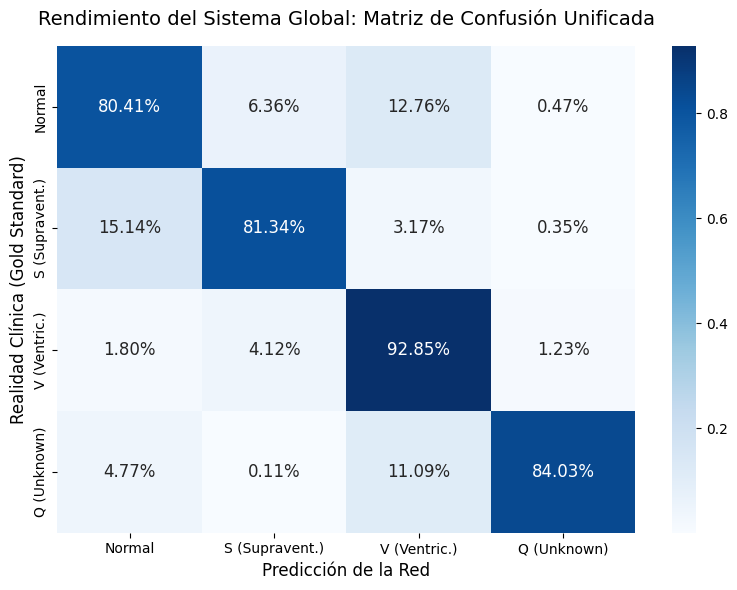


REPORTE DE CLASIFICACIÓN GLOBAL (4 CATEGORÍAS AAMI)
                precision    recall  f1-score   support

        Normal     0.9880    0.8041    0.8866     16772
S (Supravent.)     0.1674    0.8134    0.2776       284
  V (Ventric.)     0.4345    0.9285    0.5920      1944
   Q (Unknown)     0.9363    0.8403    0.8857      1803

      accuracy                         0.8190     20803
     macro avg     0.6316    0.8466    0.6605     20803
  weighted avg     0.9206    0.8190    0.8507     20803


F1-Score Macro Global del Sistema: 0.6605


In [58]:
# %%
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tensorflow.keras.models import load_model

# ==========================================
# 1. CARGA DEL MODELO COMPLETADO DE 4 CLASES
# ==========================================
print("Cargando el mejor modelo multiclase unificado...")
model_path = "../models/classificator_v1_mc_rr_w1500_s20k_4c_asimetry.keras"

model_eval = load_model(
    model_path,
    custom_objects={'loss': poly_focal_loss(gamma=2.0, epsilon=0.5, alpha_weights=weights_vector_multi)}
)

# ==========================================
# 2. PREDICCIONES SOBRE EL SET DE TEST REAL
# ==========================================
print("Realizando predicciones sobre el set de test global...")
y_pred_raw = model_eval.predict([X_test_sig_norm, X_test_rr_final_norm])

y_pred = np.argmax(y_pred_raw, axis=-1)
y_true = np.argmax(y_test_m2_onehot, axis=-1) 

labels_m2 = [0, 1, 2, 3]
classes_m2_names = ['Normal', 'S (Supravent.)', 'V (Ventric.)', 'Q (Unknown)']

# ==========================================
# 3. MATRIZ DE CONFUSIÓN GLOBAL NORMALIZADA
# ==========================================
cm = confusion_matrix(y_true, y_pred, labels=labels_m2, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='.2%', 
    cmap='Blues', 
    xticklabels=classes_m2_names, 
    yticklabels=classes_m2_names,
    annot_kws={"size": 12}
)
plt.title('Rendimiento del Sistema Global: Matriz de Confusión Unificada', fontsize=14, pad=15)
plt.ylabel('Realidad Clínica (Gold Standard)', fontsize=12)
plt.xlabel('Predicción de la Red', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 4. REPORTE DE RENDIMIENTO DEL TFG
# ==========================================
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN GLOBAL (4 CATEGORÍAS AAMI)")
print("="*60)
print(classification_report(y_true, y_pred, labels=labels_m2, target_names=classes_m2_names, digits=4))

macro_f1_global = f1_score(y_true, y_pred, labels=labels_m2, average='macro')
print(f"\nF1-Score Macro Global del Sistema: {macro_f1_global:.4f}")

In [44]:
# Multiplicadores de sensibilidad por clase: ['Normal', 'S', 'V', 'Q']
# Un valor mayor a 1.0 fuerza a la red a ser más "sensible" a esa clase.
# Un valor menor a 1.0 frena los falsos positivos de esa clase.
factores_sensibilidad = np.array([1.5, 1.0, 1.0, 1.0])

# Multiplicamos las probabilidades de salida por nuestros factores personalizados
y_pred_ajustado_raw = y_pred_raw * factores_sensibilidad

# Ahora sí, aplicamos el argmax sobre las probabilidades sesgadas clínicamente
y_pred_ajustado = np.argmax(y_pred_ajustado_raw, axis=-1)

# Imprimimos el nuevo reporte para ver el impacto
from sklearn.metrics import classification_report, f1_score
print(classification_report(y_true, y_pred_ajustado, target_names=classes_m2_names, digits=4))
macro_f1_ajustado = f1_score(y_true, y_pred_ajustado, average='macro')
print(f"Nuevo F1-Score Macro Global Ajustado: {macro_f1_ajustado:.4f}")

                precision    recall  f1-score   support

        Normal     0.9814    0.8602    0.9168     16772
S (Supravent.)     0.1779    0.7359    0.2865       284
  V (Ventric.)     0.5334    0.9151    0.6740      1944
   Q (Unknown)     0.9510    0.8403    0.8922      1803

      accuracy                         0.8619     20803
     macro avg     0.6609    0.8379    0.6924     20803
  weighted avg     0.9260    0.8619    0.8834     20803

Nuevo F1-Score Macro Global Ajustado: 0.6924
